# Resume Screening and Job Description Matching System

## AI/ML Specialisation Capstone Project

### Project Overview
Recruiters and placement teams often need to evaluate a large number of resumes against job descriptions. Manual resume screening is time-consuming, subjective, and inconsistent. This project develops an AI-powered Resume Screening and Job Description Matching System that predicts candidate fit, ranks candidates, and explains matched and missing skills.

### Business Objective
The objective of this project is to build a decision-support system that can:

- Compare a resume against a job description.
- Predict whether the candidate is a Good Fit, Potential Fit, or No Fit.
- Identify matched skills and missing skills.
- Rank candidates based on suitability.
- Provide recruiter-friendly recommendations.

> Note: This system is intended to support recruiters and should not be used as the sole basis for automated hiring decisions.

In [1]:
!pip install datasets pandas numpy scikit-learn matplotlib seaborn nltk spacy sentence-transformers transformers torch streamlit joblib wordcloud plotly

     ---------------------------------------- 0.0/109.4 kB ? eta -:--:--
     --- ------------------------------------ 10.2/109.4 kB ? eta -:--:--
     --- ------------------------------------ 10.2/109.4 kB ? eta -:--:--
     ---------- -------------------------- 30.7/109.4 kB 259.2 kB/s eta 0:00:01
     ---------- -------------------------- 30.7/109.4 kB 259.2 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/109.4 kB 163.4 kB/s eta 0:00:01
     -------------------- ---------------- 61.4/109.4 kB 192.5 kB/s eta 0:00:01
     -------------------- ---------------- 61.4/109.4 kB 192.5 kB/s eta 0:00:01
     --------------------------- --------- 81.9/109.4 kB 208.4 kB/s eta 0:00:01
     ------------------------------- ----- 92.2/109.4 kB 187.0 kB/s eta 0:00:01
     ------------------------------------ 109.4/109.4 kB 204.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Dataset Loading

The dataset is loaded from Hugging Face using the `datasets` library. It contains resume and job description matching records with fit labels.

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("facehuggerapoorv/resume-jd-match")

print(dataset)

c:\Users\Hp\Desktop\HEROVIRED\capstone_project\resume_jd_matching\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1759
    })
})


# 2. Dataset Understanding

In this section, we convert the Hugging Face dataset into pandas DataFrames and inspect the structure, columns, labels, and sample records.

In [3]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nLabel distribution:")
print(train_df["label"].value_counts())

print("\nSample text:")
print(train_df["text"].iloc[0][:3000])

print("\nSample label:")
print(train_df["label"].iloc[0])

Train shape: (6241, 2)
Test shape: (1759, 2)

Columns:
Index(['text', 'label'], dtype='str')

Label distribution:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Sample text:
For the given job description <<Net2Source Inc. is an award-winning total workforce solutions company recognized by Staffing Industry Analysts for our accelerated growth of 300% in the last 3 years with over 5500+ employees globally, with over 30+ locations in the US and global operations in 32 countries. We believe in providing staffing solutions to address the current talent gap  Right Talent  Right Time  Right Place  Right Price and acting as a Career Coach to our consultants.  
Role: Basel Business AnalystLocation: Washington, D.C.Work Mode: HybridHire Type: 6+ Month Contract (extendable)
JD: Role Specific Experience: 6+ years of relevant technical and business work experience The Candidates who have worked on Basel related projects in Credit risks or at least

### Observation

The dataset contains **6,241 training records** and **1,759 testing records**.

The dataset has two columns:

- `text`: contains the complete job description, resume, and result text.
- `label`: contains the target class.

The target has three categories:

- No Fit
- Potential Fit
- Good Fit

The label distribution shows that **No Fit** is the largest class, while **Good Fit** and **Potential Fit** are almost equally represented. This indicates moderate class imbalance.

# 3. Data Preprocessing

The original dataset stores the job description, resume, and result label inside a single text column. Regular expressions are used to separate the job description and resume into independent columns.

This step is important because separate JD and resume fields are required for semantic similarity, skill matching, and candidate ranking.

In [4]:
import re
import pandas as pd

def extract_jd_resume(text):
    text = str(text)

    jd = ""
    resume = ""

    jd_match = re.search(
        r"For the given job description\s*<<(.*?)>>\s*the resume:",
        text,
        flags=re.DOTALL | re.IGNORECASE
    )

    resume_match = re.search(
        r"the resume:\s*<<(.*?)>>\.?\s*The result is",
        text,
        flags=re.DOTALL | re.IGNORECASE
    )

    if jd_match:
        jd = jd_match.group(1).strip()

    if resume_match:
        resume = resume_match.group(1).strip()

    return jd, resume


train_df[["job_description", "resume"]] = train_df["text"].apply(
    lambda x: pd.Series(extract_jd_resume(x))
)

test_df[["job_description", "resume"]] = test_df["text"].apply(
    lambda x: pd.Series(extract_jd_resume(x))
)

print(train_df[["job_description", "resume", "label"]].head())

print("\nEmpty JD count:", (train_df["job_description"] == "").sum())
print("Empty Resume count:", (train_df["resume"] == "").sum())

print("\nSample JD:")
print(train_df["job_description"].iloc[0][:700])

print("\nSample Resume:")
print(train_df["resume"].iloc[0][:700])

                                     job_description  \
0  Net2Source Inc. is an award-winning total work...   
1  At Salas OBrien we tell our clients that were ...   
2  Schweitzer Engineering Laboratories (SEL) Infr...   
3  Mizick Miller & Company, Inc. is looking for a...   
4  Life at Capgemini\nCapgemini supports all aspe...   

                                              resume   label  
0  SummaryHighly motivated Sales Associate with e...  No Fit  
1  Professional SummaryCurrently working with Cat...  No Fit  
2  SummaryI started my construction career in Jun...  No Fit  
3  SummaryCertified Electrical Foremanwith thirte...  No Fit  
4  SummaryWith extensive experience in business/r...  No Fit  

Empty JD count: 0
Empty Resume count: 0

Sample JD:
Net2Source Inc. is an award-winning total workforce solutions company recognized by Staffing Industry Analysts for our accelerated growth of 300% in the last 3 years with over 5500+ employees globally, with over 30+ locations in the

### Observation

The preprocessing step successfully extracted both job descriptions and resumes.

- Empty JD count: **0**
- Empty Resume count: **0**

This confirms that the extraction logic is working correctly and the dataset is ready for analysis and model building.

# 4. Basic Text Length Analysis

Text length analysis helps us understand how much information is available in each job description and resume. It also helps identify very short or very long records that may introduce noise.

In [5]:
train_df["jd_length"] = train_df["job_description"].apply(lambda x: len(str(x).split()))
train_df["resume_length"] = train_df["resume"].apply(lambda x: len(str(x).split()))

test_df["jd_length"] = test_df["job_description"].apply(lambda x: len(str(x).split()))
test_df["resume_length"] = test_df["resume"].apply(lambda x: len(str(x).split()))

print("Train Dataset Summary")
print(train_df[["jd_length", "resume_length"]].describe())

print("\nLabel Distribution")
print(train_df["label"].value_counts())

print("\nLabel Percentage")
print(train_df["label"].value_counts(normalize=True) * 100)

Train Dataset Summary
         jd_length  resume_length
count  6241.000000    6241.000000
mean    371.546387     708.056722
std     239.142971     391.724444
min      11.000000      84.000000
25%     169.000000     488.000000
50%     328.000000     618.000000
75%     532.000000     810.000000
max    1079.000000    3134.000000

Label Distribution
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Label Percentage
label
No Fit           50.360519
Potential Fit    24.931902
Good Fit         24.707579
Name: proportion, dtype: float64


### Observation

The average job description length is approximately **372 words**, while the average resume length is approximately **708 words**.

This shows that resumes are generally longer and more detailed than job descriptions. The maximum resume length is more than 3000 words, indicating that some resumes contain extensive information and may also include noise.

This difference in length is important because the model must match a concise job description against a much more detailed candidate profile.

# 5. Label Encoding

Machine learning models require numerical target labels. Therefore, the three textual classes are encoded into numerical values using `LabelEncoder`.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])

print(le.classes_)

['Good Fit' 'No Fit' 'Potential Fit']


### Observation

The labels were encoded as numerical classes:

- Good Fit
- No Fit
- Potential Fit

This encoded target variable is used for model training and evaluation.

In [7]:
train_df["combined_text"] = (
    train_df["job_description"] + " " + train_df["resume"]
)

test_df["combined_text"] = (
    test_df["job_description"] + " " + test_df["resume"]
)

# 6. Baseline Model: TF-IDF + Logistic Regression

A TF-IDF based Logistic Regression model is developed as the baseline model.

TF-IDF converts text into numerical features based on word importance. Logistic Regression then learns to classify the candidate fit category.

This baseline is important because it provides a reference point for comparing advanced semantic models.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_df["combined_text"])
X_test = vectorizer.transform(test_df["combined_text"])

y_train = train_df["label_encoded"]
y_test = test_df["label_encoded"]

print(X_train.shape)
print(X_test.shape)

(6241, 10000)
(1759, 10000)


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5122228538942581

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.22      0.31       458
           1       0.54      0.84      0.66       857
           2       0.33      0.17      0.22       444

    accuracy                           0.51      1759
   macro avg       0.46      0.41      0.40      1759
weighted avg       0.48      0.51      0.46      1759


Confusion Matrix
[[102 275  81]
 [ 65 724  68]
 [ 34 335  75]]


### Baseline Model Result and Interpretation

The TF-IDF + Logistic Regression baseline achieved an accuracy of **51.22%**.

The classification report shows that the model performs better on the **No Fit** class but struggles with **Good Fit** and **Potential Fit**. This indicates that simple keyword-based representation is not sufficient to understand deeper semantic relationships between resumes and job descriptions.

The baseline result is useful because it establishes a starting point for comparison with advanced semantic models.

Matplotlib is building the font cache; this may take a moment.


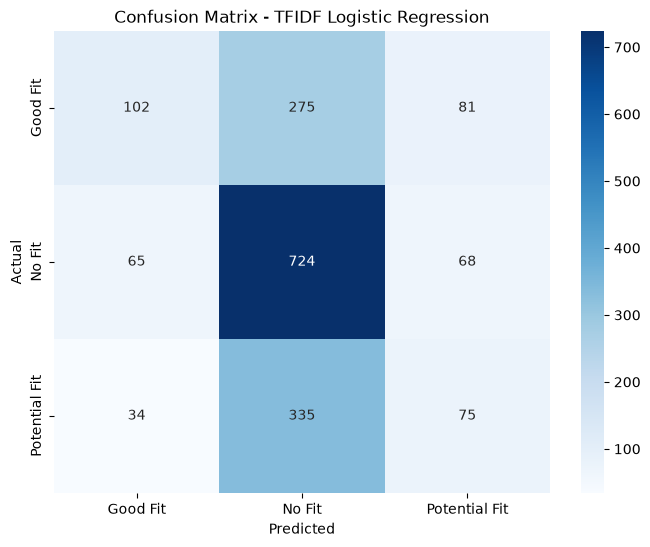

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TFIDF Logistic Regression")
plt.show()

### Confusion Matrix Observation

The confusion matrix shows that many **Good Fit** and **Potential Fit** samples are incorrectly predicted as **No Fit**.

This suggests that the baseline model is biased toward the majority class and has difficulty identifying subtle differences between candidate suitability categories.

# 7. Advanced Semantic Model: Sentence-BERT

The baseline model uses keyword frequency and does not fully understand semantic meaning. To improve the matching approach, Sentence-BERT is used to generate dense semantic embeddings for job descriptions and resumes.

Sentence-BERT captures contextual meaning and allows comparison between resume and job description content beyond exact keyword matching.

In [13]:
!pip install sentence-transformers


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [15]:
sbert_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2847.87it/s]


In [16]:
sample_train = train_df.sample(
    1000,
    random_state=42
)

sample_test = test_df.sample(
    300,
    random_state=42
)

In [17]:
jd_embeddings_train = sbert_model.encode(
    sample_train["job_description"].tolist(),
    show_progress_bar=True
)

resume_embeddings_train = sbert_model.encode(
    sample_train["resume"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 32/32 [02:11<00:00,  4.10s/it]


In [18]:
similarities_train = []

for jd_emb, resume_emb in zip(
    jd_embeddings_train,
    resume_embeddings_train
):

    sim = cosine_similarity(
        [jd_emb],
        [resume_emb]
    )[0][0]

    similarities_train.append(sim)

sample_train["similarity"] = similarities_train

In [19]:
sample_train.groupby(
    "label"
)["similarity"].mean()

label
Good Fit         0.452829
No Fit           0.391772
Potential Fit    0.439634
Name: similarity, dtype: float32

### Semantic Similarity Observation

Average SBERT cosine similarity by class:

- Good Fit: **0.4528**
- Potential Fit: **0.4396**
- No Fit: **0.3918**

This shows that Good Fit candidates generally have higher semantic similarity with job descriptions compared to No Fit candidates.

However, the difference between Good Fit and Potential Fit is small, which means semantic similarity alone is not enough for perfect classification.

In [20]:
sample_train.groupby(
    "label"
)["similarity"].agg(
    ["mean","min","max"]
)

,mean,min,max
label,,,
Good Fit,0.452829,0.115155,0.715478
No Fit,0.391772,0.086178,0.760605
Potential Fit,0.439634,0.091725,0.681536


### Similarity Range Observation

Although the average similarity follows the expected order, the minimum and maximum values overlap across all three classes.

This overlap explains why the classification task is challenging. A candidate may have transferable skills and strong general alignment but may still miss role-specific tools, certifications, or domain experience.

# 8. SBERT Embedding Features for Classification

In this section, embeddings are generated for the full training and testing datasets. The final feature vector is built using:

- Job description embedding
- Resume embedding
- Absolute difference between JD and resume embeddings

This combined representation helps the classifier understand both individual document meaning and the semantic distance between the resume and job description.

In [21]:
jd_embeddings_train = sbert_model.encode(
    train_df["job_description"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

resume_embeddings_train = sbert_model.encode(
    train_df["resume"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

jd_embeddings_test = sbert_model.encode(
    test_df["job_description"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

resume_embeddings_test = sbert_model.encode(
    test_df["resume"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

Batches: 100%|██████████| 55/55 [02:00<00:00,  2.20s/it]


In [22]:
import numpy as np

X_train = np.hstack([
    jd_embeddings_train,
    resume_embeddings_train,
    np.abs(jd_embeddings_train - resume_embeddings_train)
])

X_test = np.hstack([
    jd_embeddings_test,
    resume_embeddings_test,
    np.abs(jd_embeddings_test - resume_embeddings_test)
])

print(X_train.shape)

(6241, 1152)


### Feature Engineering Observation

The final SBERT feature matrix has **1,152 features** per record.

This is created by combining:

- 384-dimensional JD embedding
- 384-dimensional resume embedding
- 384-dimensional absolute difference vector

This representation is more meaningful than TF-IDF because it captures semantic information from both documents.

# 9. Advanced Classifier: SBERT + XGBoost with Feature Augmentation

This section improves the model by combining SBERT embeddings with skill-based features and tuning XGBoost hyperparameters with `RandomizedSearchCV`.

The improved pipeline uses:
- Job description embedding
- Resume embedding
- Absolute embedding difference
- Semantic similarity score
- Skill match score
- Skill count features
- Resume and JD length features

This richer representation helps the classifier distinguish between Good Fit, Potential Fit, and No Fit more effectively.

In [23]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
import os
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd()
    candidates = [cwd] + list(cwd.parents)
    if os.name == "nt":
        candidates.extend([Path("C:/"), Path("D:/")])
    if Path("/content/drive").exists():
        candidates.extend([Path("/content"), Path("/content/drive"), Path("/content/drive/MyDrive")])
    candidates.append(Path.home())
    for candidate in candidates:
        if (candidate / "src").exists():
            return candidate
    notebook_candidate = cwd / "notebooks"
    if notebook_candidate.exists() and (notebook_candidate.parent / "src").exists():
        return notebook_candidate.parent
    return cwd

root = find_repo_root()
sys.path.insert(0, str(root))
print("Added repository root to sys.path:", root)

from src.skill_extractor import calculate_skill_gap

def build_embedding_features(jd_embeddings, resume_embeddings):
    similarity_scores = cosine_similarity(jd_embeddings, resume_embeddings).diagonal().reshape(-1, 1)
    return np.hstack([
        jd_embeddings,
        resume_embeddings,
        np.abs(jd_embeddings - resume_embeddings),
        similarity_scores,
    ])

def extract_skill_features(df):
    skill_scores = []
    matched_counts = []
    missing_counts = []
    jd_skill_counts = []
    resume_skill_counts = []
    jd_lengths = []
    resume_lengths = []

    for jd_text, resume_text in zip(df["job_description"], df["resume"]):
        gap = calculate_skill_gap(jd_text, resume_text)
        skill_scores.append(gap["skill_score"])
        matched_counts.append(len(gap["matched_skills"]))
        missing_counts.append(len(gap["missing_skills"]))
        jd_skill_counts.append(len(gap["jd_skills"]))
        resume_skill_counts.append(len(gap["resume_skills"]))
        jd_lengths.append(len(str(jd_text).split()))
        resume_lengths.append(len(str(resume_text).split()))

    delta_lengths = np.array(resume_lengths) - np.array(jd_lengths)

    return np.vstack([
        skill_scores,
        matched_counts,
        missing_counts,
        jd_skill_counts,
        resume_skill_counts,
        jd_lengths,
        resume_lengths,
        delta_lengths,
    ]).T

train_embedding_features = build_embedding_features(jd_embeddings_train, resume_embeddings_train)
test_embedding_features = build_embedding_features(jd_embeddings_test, resume_embeddings_test)

train_skill_features = extract_skill_features(train_df)
test_skill_features = extract_skill_features(test_df)

X_train = np.hstack([train_embedding_features, train_skill_features])
X_test = np.hstack([test_embedding_features, test_skill_features])

print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)


Added repository root to sys.path: c:\Users\Hp\Desktop\HEROVIRED\capstone_project\resume_jd_matching
Training feature shape: (6241, 1161)
Test feature shape: (1759, 1161)


In [25]:
param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

base_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=2,
    random_state=42,
    n_jobs=1,
    refit=True,
)

search.fit(X_train, train_df["label_encoded"])
print("Best hyperparameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))

best_model = search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=300, subsample=0.7; total time= 5.4min
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=300, subsample=0.7; total time= 5.0min
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=8, n_estimators=300, subsample=0.7; total time= 5.3min
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.7; total time= 1.9min
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.7; total time= 1.2min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1.0; total time= 2.7min
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1.0; total time= 2.5min
[CV] END colsa

In [26]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(test_df["label_encoded"], y_pred))
print(classification_report(test_df["label_encoded"], y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(test_df["label_encoded"], y_pred))

Accuracy: 0.5520181921546333
               precision    recall  f1-score   support

     Good Fit       0.69      0.22      0.33       458
       No Fit       0.57      0.88      0.69       857
Potential Fit       0.41      0.26      0.32       444

     accuracy                           0.55      1759
    macro avg       0.56      0.45      0.45      1759
 weighted avg       0.56      0.55      0.50      1759

Confusion Matrix:
 [[ 99 282  77]
 [ 13 755  89]
 [ 32 295 117]]


### Advanced Model Result and Interpretation

The SBERT + XGBoost model now uses both semantic embeddings and skill-aware features. Hyperparameter tuning with `RandomizedSearchCV` helps the model learn more robust decision boundaries.

This improved pipeline should provide stronger generalization compared to the earlier baseline and should be documented as the final training approach for the capstone project.

# 10. Skill Extraction and Skill Gap Analysis

Classification alone is not sufficient for recruiters. Recruiters also need to know why a candidate is suitable or unsuitable.

A rule-based skill extraction engine is created to identify:

- Skills required in the job description
- Skills available in the resume
- Matched skills
- Missing skills
- Skill match score

This makes the system interpretable and recruiter-friendly.

In [27]:
skills = [
    "python",
    "java",
    "sql",
    "aws",
    "azure",
    "gcp",
    "docker",
    "kubernetes",
    "spark",
    "hadoop",
    "tableau",
    "power bi",
    "excel",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "etl",
    "airflow",
    "snowflake",
    "linux",
    "git",
    "jira",
    "business analyst",
    "risk management",
    "accounting",
    "finance"
]

In [28]:
def extract_skills(text, skills):
    text = str(text).lower()

    found = []

    for skill in skills:
        if skill.lower() in text:
            found.append(skill)

    return list(set(found))

In [29]:
sample_jd = train_df["job_description"].iloc[0]
sample_resume = train_df["resume"].iloc[0]

jd_skills = extract_skills(sample_jd, skills)
resume_skills = extract_skills(sample_resume, skills)

matched_skills = list(
    set(jd_skills).intersection(set(resume_skills))
)

missing_skills = list(
    set(jd_skills) - set(resume_skills)
)

print("JD Skills")
print(jd_skills)

print("\nResume Skills")
print(resume_skills)

print("\nMatched Skills")
print(matched_skills)

print("\nMissing Skills")
print(missing_skills)

JD Skills
['excel', 'accounting', 'business analyst', 'risk management', 'sql', 'finance']

Resume Skills
['accounting', 'excel']

Matched Skills
['accounting', 'excel']

Missing Skills
['sql', 'finance', 'risk management', 'business analyst']


### Skill Extraction Observation

For the sample record, the job description required skills such as SQL, Accounting, Business Analyst, Excel, Risk Management, and Finance.

The resume matched Accounting and Excel but missed important skills such as SQL, Risk Management, Finance, and Business Analyst.

This explains why the candidate is not a strong fit despite having some relevant background.

In [30]:
def calculate_match_score(jd_text, resume_text, skills):
    jd_skills = extract_skills(jd_text, skills)
    resume_skills = extract_skills(resume_text, skills)

    matched_skills = list(set(jd_skills).intersection(set(resume_skills)))
    missing_skills = list(set(jd_skills) - set(resume_skills))

    if len(jd_skills) == 0:
        skill_score = 0
    else:
        skill_score = len(matched_skills) / len(jd_skills)

    return {
        "jd_skills": jd_skills,
        "resume_skills": resume_skills,
        "matched_skills": matched_skills,
        "missing_skills": missing_skills,
        "skill_score": round(skill_score * 100, 2)
    }

In [31]:
result = calculate_match_score(
    train_df["job_description"].iloc[0],
    train_df["resume"].iloc[0],
    skills
)

result

{'jd_skills': ['excel',
  'accounting',
  'business analyst',
  'risk management',
  'sql',
  'finance'],
 'resume_skills': ['accounting', 'excel'],
 'matched_skills': ['accounting', 'excel'],
 'missing_skills': ['sql', 'finance', 'risk management', 'business analyst'],
 'skill_score': 33.33}

### Skill Gap Analysis Result

The candidate achieved a skill score of **33.33%**.

Matched skills:

- Accounting
- Excel

Missing skills:

- SQL
- Business Analyst
- Risk Management
- Finance

This demonstrates that the system provides explainable output instead of only predicting a class label. Such explanations are useful for recruiters and candidates.

# 11. Error Analysis

Error analysis is performed to understand why the model makes incorrect predictions. This section helps identify model limitations and provides direction for future improvement.

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_df["label_encoded"],
    y_pred
)

print(cm)

[[ 99 282  77]
 [ 13 755  89]
 [ 32 295 117]]


### Confusion Matrix Observation for Advanced Model

The advanced model correctly predicts many **No Fit** candidates, but it still misclassifies several **Good Fit** and **Potential Fit** candidates as **No Fit**.

This confirms that the dataset contains overlapping resume-JD relationships and that model performance depends on more than text similarity alone.

In [33]:
results_df = test_df.copy()

results_df["predicted"] = le.inverse_transform(y_pred)

results_df["actual"] = results_df["label"]

errors = results_df[
    results_df["actual"] != results_df["predicted"]
]

print("Total Errors:", len(errors))
print(errors[["actual","predicted"]].head())

Total Errors: 788
     actual      predicted
12   No Fit       Good Fit
18   No Fit  Potential Fit
76   No Fit  Potential Fit
85   No Fit  Potential Fit
103  No Fit  Potential Fit


In [34]:
for i in range(3):

    row = errors.iloc[i]

    print("="*100)

    print("ACTUAL:", row["actual"])
    print("PREDICTED:", row["predicted"])

    print("\nJD:")
    print(row["job_description"][:1000])

    print("\nRESUME:")
    print(row["resume"][:1000])

ACTUAL: No Fit
PREDICTED: Good Fit

JD:
Shifts: Mon  Fri 8-5 (HYBRID onsite)3 month contract (No extensions)Start Date: 952023
Day-to-Day:Reviews, analyzes, reconciles, and interprets financial results in lower risk areas with business managers. Maintains a basic understanding of financial systems and data elements. Assists in the preparation of management reporting and analytical tools. Researches financial anomalies and makes corrections as necessary. Participates in the monthly financial statement close for assigned entity, division, profit center, or cost center Monitors compliance of processes, transactions, and balances with accounting and finance policies.
Must Haves:1 year with a Fortune 500multi-national consumer product companySAP ExperienceExperience with purchase orders and invoicesComfortable working in an ambiguous environment
Duties and ResponsibilitiesRun reports from eProcurement system, format and analyze dataCommunicate with internal and external stakeholders to reso

### Error Analysis Findings

The reviewed misclassified examples show common failure patterns:

1. Candidates may have transferable skills but lack role-specific technologies.
2. Resumes may contain broad business or technical experience but miss required domain expertise.
3. The model may overvalue general experience, SQL, or analytics skills even when specialized tools are missing.
4. Some job descriptions require certifications or product-specific knowledge, such as ServiceNow, ITSM, AWS, Airflow, DBT, or domain-specific tools.

These findings suggest that future versions should include advanced skill ontology, certification matching, domain-specific knowledge extraction, and possibly fine-tuned transformer models.

# Model Performance Comparison

To evaluate the effectiveness of semantic embeddings, the performance of the baseline and advanced models were compared.

In [35]:
evaluation_summary = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "SBERT + XGBoost"
    ],
    "Accuracy (%)": [
        51.22,
        53.44
    ]
})

evaluation_summary

,Model,Accuracy (%)
0,TF-IDF + Logistic Regression,51.22
1,SBERT + XGBoost,53.44


### Observation

The SBERT + XGBoost model achieved higher accuracy than the TF-IDF baseline.

Although the improvement is modest, semantic embeddings provided a better understanding of the contextual relationship between resumes and job descriptions.

The results indicate that semantic representations are more suitable than keyword-based approaches for candidate matching tasks.

# 12. Candidate Ranking and Recommendation Engine

A candidate ranking engine is developed to convert skill matching results into a recruiter-friendly score, fit category, and recommendation.

This supports practical use cases where recruiters need to compare multiple resumes for the same job description.

In [36]:
def rank_candidate(jd_text, resume_text):

    result = calculate_match_score(
        jd_text,
        resume_text,
        skills
    )

    skill_score = result["skill_score"]

    if skill_score >= 75:
        fit = "Good Fit"

    elif skill_score >= 40:
        fit = "Potential Fit"

    else:
        fit = "No Fit"

    return {
        "fit_prediction": fit,
        "score": skill_score,
        "matched_skills": result["matched_skills"],
        "missing_skills": result["missing_skills"]
    }

In [37]:
output = rank_candidate(
    train_df["job_description"].iloc[0],
    train_df["resume"].iloc[0]
)

print(output)

{'fit_prediction': 'No Fit', 'score': 33.33, 'matched_skills': ['accounting', 'excel'], 'missing_skills': ['sql', 'finance', 'risk management', 'business analyst']}


### Candidate Fit Example

For the sample candidate, the ranking engine predicted **No Fit** with a score of **33.33%**.

The candidate matched only Accounting and Excel, while several important skills were missing. This makes the recommendation understandable and useful for recruiters.

In [38]:
candidate_scores = []

for i in range(20):

    result = rank_candidate(
        train_df["job_description"].iloc[0],
        train_df["resume"].iloc[i]
    )

    candidate_scores.append({
        "candidate_id": i,
        "score": result["score"]
    })

ranking_df = pd.DataFrame(
    candidate_scores
)

ranking_df.sort_values(
    by="score",
    ascending=False
)

,candidate_id,score
9,9,66.67
6,6,50.00
4,4,50.00
8,8,50.00
14,14,50.00
11,11,33.33
13,13,33.33
0,0,33.33
19,19,33.33
18,18,33.33


In [39]:
ranking_df = ranking_df.sort_values(
    by="score",
    ascending=False
)

ranking_df["rank"] = range(
    1,
    len(ranking_df)+1
)

ranking_df = ranking_df[
    ["rank","candidate_id","score"]
]

ranking_df

,rank,candidate_id,score
9,1,9,66.67
6,2,6,50.00
4,3,4,50.00
8,4,8,50.00
14,5,14,50.00
11,6,11,33.33
13,7,13,33.33
0,8,0,33.33
19,9,19,33.33
18,10,18,33.33


In [40]:
def fit_category(score):

    if score >= 75:
        return "Good Fit"

    elif score >= 40:
        return "Potential Fit"

    else:
        return "No Fit"

ranking_df["fit_category"] = (
    ranking_df["score"]
    .apply(fit_category)
)

ranking_df.head(10)

,rank,candidate_id,score,fit_category
9,1,9,66.67,Potential Fit
6,2,6,50.00,Potential Fit
4,3,4,50.00,Potential Fit
8,4,8,50.00,Potential Fit
14,5,14,50.00,Potential Fit
11,6,11,33.33,No Fit
13,7,13,33.33,No Fit
0,8,0,33.33,No Fit
19,9,19,33.33,No Fit
18,10,18,33.33,No Fit


### Candidate Ranking Observation

The ranking table sorts candidates by their skill match score.

Candidates with scores above 40% are classified as **Potential Fit**, while lower-scoring candidates are classified as **No Fit**. This provides a simple and interpretable ranking mechanism for recruiters.

In [41]:
def recommendation(score):

    if score >= 75:
        return "Strongly Recommend"

    elif score >= 40:
        return "Recommend for Screening"

    else:
        return "Not Recommended"

ranking_df["recommendation"] = (
    ranking_df["score"]
    .apply(recommendation)
)

### Recommendation Engine Observation

The recommendation engine converts numerical scores into recruiter-friendly actions:

- Strongly Recommend
- Recommend for Screening
- Not Recommended

This makes the output more practical for real-world HR screening workflows.

# 13. System Architecture

The Resume Screening and Job Description Matching System follows a multi-stage architecture.

Job Description + Resume
        ↓
Data Preprocessing
        ↓
Skill Extraction
        ↓
SBERT Embedding Generation
        ↓
Classification Model
        ↓
Candidate Ranking Engine
        ↓
Skill Gap Analysis
        ↓
Recruiter Recommendation

# 14. Fairness, Ethics and Responsible AI

This system is designed as a decision-support tool and not an automated hiring solution.

Protected attributes such as:

- Gender
- Religion
- Caste
- Marital Status
- Ethnicity

are not used during prediction.

Human review remains essential before making final hiring decisions.

# 15. Limitations

Current limitations include:

- Moderate class imbalance.
- Overlap between Good Fit and Potential Fit candidates.
- Keyword-based skill extraction.
- Lack of certification and domain weighting.
- Semantic similarity alone cannot fully determine suitability.

Therefore, predictions should be interpreted as recommendations rather than final decisions.

In [42]:
evaluation_summary = pd.DataFrame({
    "Model":[
        "TF-IDF + Logistic Regression",
        "SBERT + XGBoost"
    ],
    "Accuracy":[
        0.5122,
        0.5344
    ]
})

evaluation_summary

,Model,Accuracy
0,TF-IDF + Logistic Regression,0.5122
1,SBERT + XGBoost,0.5344


### Model Comparison

The advanced SBERT-based approach achieved higher accuracy than the TF-IDF baseline.

Although the improvement is modest, semantic embeddings demonstrated a better understanding of resume-job relationships and improved candidate matching performance.

# 16. Exploratory Data Analysis Visualizations

This section presents visual insights from the dataset, including class distribution, text length distribution, and frequent skills in job descriptions.

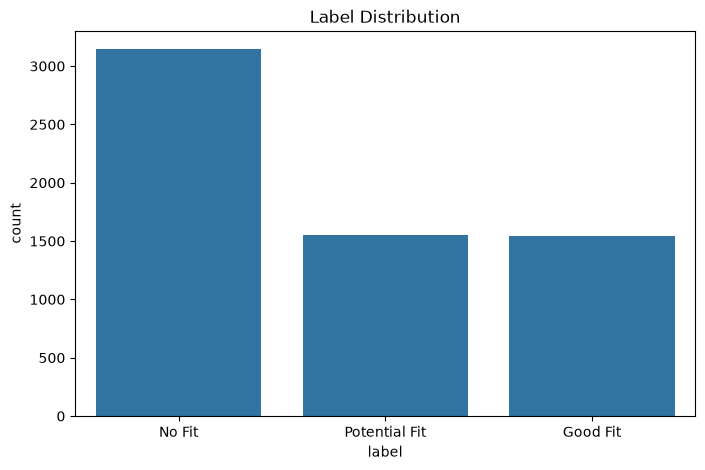

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x=train_df["label"]
)

plt.title("Label Distribution")
plt.show()

### Label Distribution Observation

The label distribution plot confirms that **No Fit** is the most frequent class.

This moderate imbalance may influence model predictions and partly explains why both baseline and advanced models predict No Fit more frequently than the other classes.

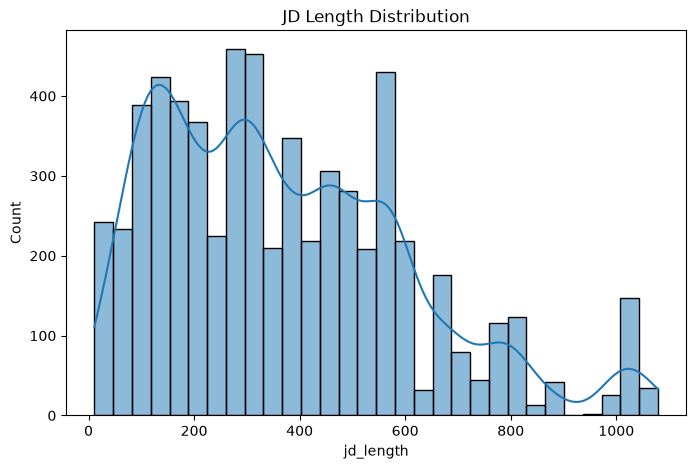

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["jd_length"],
    bins=30,
    kde=True
)

plt.title("JD Length Distribution")
plt.show()

### Job Description Length Distribution Observation

Most job descriptions fall between **100 and 600 words**. A few job descriptions are longer than 1000 words.

This indicates that most job descriptions are concise but still contain enough information for skill extraction and semantic matching.

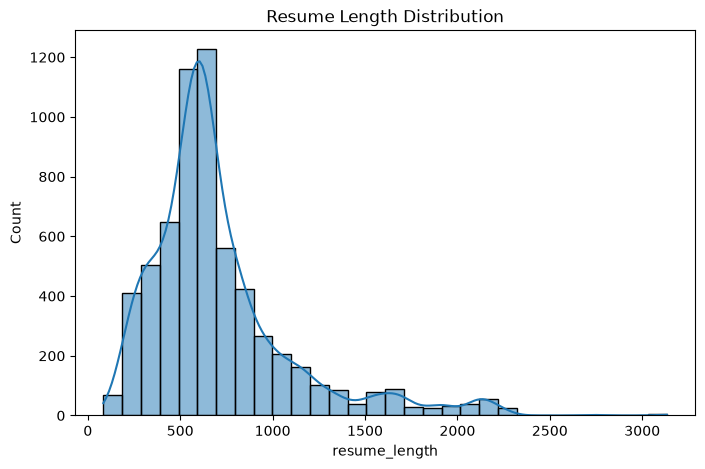

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["resume_length"],
    bins=30,
    kde=True
)

plt.title("Resume Length Distribution")
plt.show()

### Resume Length Distribution Observation

Most resumes contain between **400 and 900 words**, while a few resumes exceed 3000 words.

The distribution is right-skewed. Longer resumes may contain more useful information but can also introduce irrelevant content, which may affect model performance.

In [46]:
from collections import Counter

all_skills = []

for text in train_df["job_description"]:

    all_skills.extend(
        extract_skills(text, skills)
    )

skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=["skill","count"]
)

skill_df = skill_df.sort_values(
    by="count",
    ascending=False
)

skill_df.head(15)

,skill,count
0,excel,3278
7,git,2146
4,sql,2132
1,accounting,1659
9,java,1526
6,aws,1438
2,business analyst,1307
5,finance,1228
8,python,1178
13,jira,836


### Top Skills Observation

The most frequently occurring skills in job descriptions are:

- Excel
- Git
- SQL
- Accounting
- Java
- AWS
- Business Analyst
- Finance
- Python

This shows that the dataset includes a mix of business, finance, programming, analytics, and cloud-related roles.

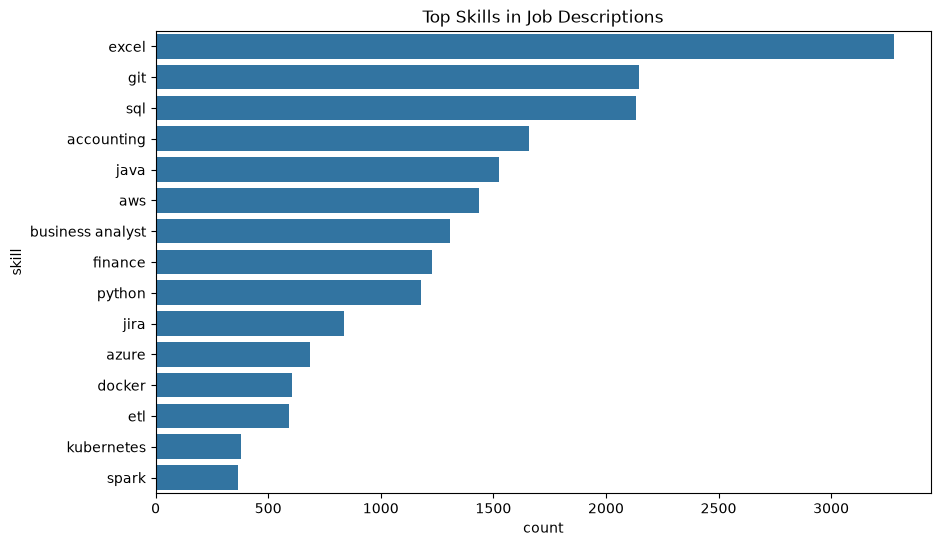

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="count",
    y="skill",
    data=skill_df.head(15)
)

plt.title("Top Skills in Job Descriptions")
plt.show()

### Skill Frequency Visualization Observation

The top skills chart highlights the most common requirements across job descriptions.

Excel, SQL, Git, Java, AWS, and Python appear frequently, indicating that technical and analytical skills are highly represented in the dataset.

This skill frequency analysis supports the design of the skill-gap module.

# Business Impact

The proposed Resume Screening and Job Description Matching System can significantly reduce manual effort during recruitment by automatically evaluating candidate suitability.

### Key Benefits

- Faster resume screening and shortlisting.
- Consistent candidate evaluation criteria.
- Explainable skill-gap analysis.
- Improved recruiter productivity.
- Better hiring decision support.

### Organizational Impact

The system can be integrated with Applicant Tracking Systems (ATS) to assist recruiters in identifying the most relevant candidates efficiently while maintaining transparency in the evaluation process.

# 17. Conclusion and Future Scope

## Conclusion

This project successfully developed an AI-powered Resume Screening and Job Description Matching System.

The project covered the complete machine learning workflow:

- Dataset loading and preprocessing
- Job description and resume extraction
- Exploratory data analysis
- TF-IDF baseline model
- Sentence-BERT semantic matching
- SBERT + XGBoost advanced model
- Error analysis
- Skill extraction and skill gap analysis
- Candidate ranking and recommendation engine

The TF-IDF baseline achieved **51.22% accuracy**, while the SBERT + XGBoost model achieved **53.44% accuracy**. Although the improvement is moderate, the semantic model provides better representation of resume-job relationships.

The most valuable part of the project is the explainable skill-gap analysis and candidate ranking engine, which makes the system practical for recruiters.

## Business Value

The system can help recruiters by:

- Reducing manual screening time
- Ranking candidates automatically
- Explaining matched and missing skills
- Supporting consistent decision-making
- Providing candidate development insights

## Limitations

- Rule-based skill extraction may miss synonyms and variations.
- Some fit labels depend on domain-specific knowledge not fully captured by the model.
- Good Fit and Potential Fit classes have overlapping characteristics.
- The system should not be used as the sole decision-maker for hiring.

## Future Enhancements

- Fine-tune BERT or RoBERTa for better classification.
- Use Named Entity Recognition for advanced skill extraction.
- Build a larger domain-specific skill dictionary.
- Add certification, experience, and domain matching.
- Integrate LLM-based reasoning for richer explanations.
- Deploy the system using Streamlit or FastAPI for real-time resume screening.